In [13]:
import os
import numpy as np
import pandas as pd
import FinanceDataReader as fdr
from typing import Dict, List, Optional
import matplotlib.pyplot as plt


In [2]:
def load_stock_data(simbol, start_date):
    try:
        df = fdr.DataReader(simbol, start_date)
        if start_date in df.index:
            return df.loc[start_date]
        else:
            print(f"해당 일에 대한 지수 값이 없음 / {simbol} / {start_date}")
            return None
    except KeyError as e:
        print(f"해당 일에 대한 지수 값이 없음 / {simbol} / {e}")
        return None
    except Exception as e:
        print(f"일반적인 오류 발생 / {simbol} / {e}")
        return None

    return df


In [3]:
def collect_indices(start_date, symbol_map):
    # 심볼 → 지수 이름 매핑을 함수 안에서 처리
    results = []

    for name, symbol in symbol_map.items():
        data = load_stock_data(symbol, start_date)
        if data is not None:
            row = {
                "stock": name,
                "date": start_date,
                "Open": data["Open"],
                "High": data["High"],
                "Low": data["Low"],
                "Close": data["Close"],
                "Volume": data["Volume"]
            }
            results.append(row)

    df_result = pd.DataFrame(results)
    return df_result



In [4]:
def add_daily_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds:
    - ret_pct: (Close-Open)/Open * 100
    - range_pct: (High-Low)/Open * 100
    - close_over_open: Close/Open
    - candle_dir: +1 (up) / -1 (down) / 0
    """
    out = df.copy()

    for col in ["Open", "High", "Low", "Close"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["ret_pct"] = (out["Close"] - out["Open"]) / out["Open"] * 100.0
    out["range_pct"] = (out["High"] - out["Low"]) / out["Open"] * 100.0
    out["close_over_open"] = out["Close"] / out["Open"]

    out["candle_dir"] = np.sign(out["Close"] - out["Open"]).astype(int)
    return out

In [5]:
def plot_daily_return_bar(dfm: pd.DataFrame, title: Optional[str] = None) -> plt.Figure:
    d = dfm.sort_values("ret_pct", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(d["stock"], d["ret_pct"])
    ax.axvline(0, linewidth=1)
    ax.set_xlabel("Daily return (%)")
    ax.set_ylabel("Asset")
    ax.set_title(title or f"Daily Return by Asset ({d['date'].iloc[0]})")
    ax.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    return fig

In [6]:
def plot_intraday_range_bar(dfm: pd.DataFrame, title: Optional[str] = None) -> plt.Figure:
    d = dfm.sort_values("range_pct", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(d["stock"], d["range_pct"])
    ax.set_xlabel("Intraday range (High-Low) / Open (%)")
    ax.set_ylabel("Asset")
    ax.set_title(title or f"Intraday Range by Asset ({d['date'].iloc[0]})")
    ax.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    return fig


In [7]:
def plot_candlestick_one_day(
    dfm: pd.DataFrame,
    stocks: List[str],
    title: Optional[str] = None,
) -> plt.Figure:
    d = dfm[dfm["stock"].isin(stocks)].copy()

    # Keep original order of `stocks`
    d["stock"] = pd.Categorical(d["stock"], categories=stocks, ordered=True)
    d = d.sort_values("stock")

    fig, ax = plt.subplots(figsize=(3, 5))
    x = np.arange(len(d))

    # Wicks
    ax.vlines(x, d["Low"], d["High"], linewidth=1)

    # Bodies
    body_bottom = np.minimum(d["Open"], d["Close"])
    body_top = np.maximum(d["Open"], d["Close"])
    body_height = (body_top - body_bottom).replace(0, np.nan)  # avoid zero-height rectangles

    # 색상 조건: Open < Close → 파란색, Open > Close → 빨간색
    colors = np.where(d["Open"] < d["Close"], "blue", "red")

    # Bodies with colors
    ax.bar(x, (body_top - body_bottom), bottom=body_bottom, width=0.6, color=colors)

    ax.set_xticks(x)
    ax.set_xticklabels(d["stock"], rotation=0)
    ax.set_ylabel("Price / Index Level")
    ax.set_title(title or f"1-day Candle ({d['date'].iloc[0]})")
    ax.grid(axis="y", alpha=0.2)
    fig.tight_layout()
    return fig

In [8]:
def plot_volume_vs_return_scatter(dfm: pd.DataFrame, title: Optional[str] = None) -> plt.Figure:
    d = dfm.copy()
    d["Volume"] = pd.to_numeric(d["Volume"], errors="coerce")
    d = d[(d["Volume"].notna()) & (d["Volume"] > 0)].copy()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(d["Volume"], d["ret_pct"])
    ax.set_xscale("log")  # volume range is often huge
    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Volume (log scale)")
    ax.set_ylabel("Daily return (%)")
    ax.set_title(title or f"Volume vs Return ({dfm['date'].iloc[0]})")
    ax.grid(alpha=0.2)

    # Label points (keep it light; if too many assets, you may disable)
    for _, r in d.iterrows():
        ax.annotate(str(r["stock"]), (r["Volume"], r["ret_pct"]), fontsize=9, xytext=(4, 4),
                    textcoords="offset points")

    fig.tight_layout()
    return fig


In [9]:
symbol_map = {
        "NASDAQ": "IXIC",
        "S&P500": "US500",
        "DOWJONES": "DJI",
        "RUSSELL2000": "RUT",
        "USD/KRW": "USD/KRW",
        "Dallor Index/USD": "DX-Y.NYB",
        "GOLD": "GC=F",
        "BITCOIN": "BTC/USD",
        "VIX": "VIX",
        "US5YT": "US5YT",
        "US10YT": "US10YT",
        "US30YT": "US30YT",
}

stock_list = ["NASDAQ", "S&P500", "DOWJONES", "RUSSELL2000", "BITCOIN"]

In [10]:
start_date = "2025-12-24"
folder_name = start_date.replace("-", "")
df_indices = collect_indices(start_date, symbol_map)
print(df_indices)

               stock        date          Open          High           Low  \
0             NASDAQ  2025-12-24  23555.949219  23621.720703  23527.970703   
1             S&P500  2025-12-24   6904.910156   6937.319824   6904.910156   
2           DOWJONES  2025-12-24  48424.710938  48771.320312  48386.589844   
3        RUSSELL2000  2025-12-24   2539.330078   2549.959961   2535.129883   
4            USD/KRW  2025-12-24   1478.670044   1478.670044   1429.689941   
5   Dallor Index/USD  2025-12-24     97.889999     98.010002     97.750000   
6               GOLD  2025-12-24   4500.700195   4503.399902   4468.399902   
7            BITCOIN  2025-12-24  87404.320312  87956.882812  86411.796875   
8                VIX  2025-12-24     14.090000     14.160000     13.380000   
9              US5YT  2025-12-24      3.743000      3.743000      3.713000   
10            US10YT  2025-12-24      4.167000      4.167000      4.132000   
11            US30YT  2025-12-24      4.828000      4.829000    

In [17]:
df = add_daily_metrics(df_indices)
stock_df = df[df['stock'].isin(stock_list)]

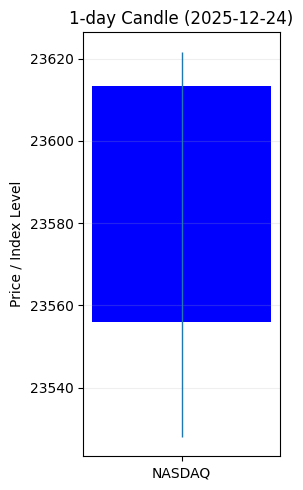

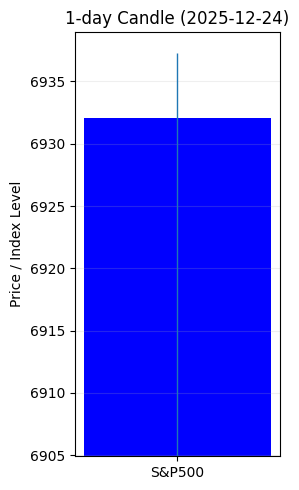

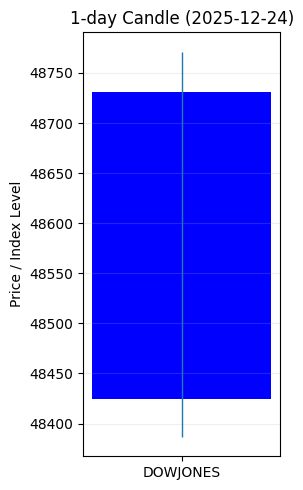

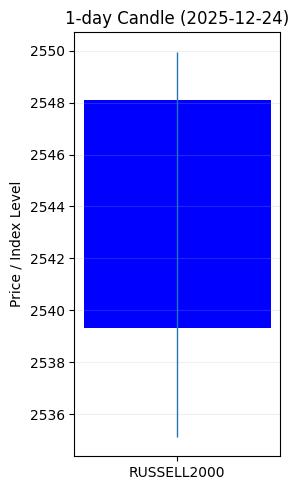

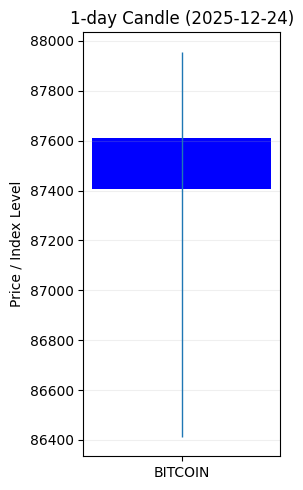

In [18]:
if not os.path.exists(f"./figs/{folder_name}"):
    os.makedirs(f"./figs/{folder_name}")

for stock in stock_list:
    plot_candlestick_one_day(df, [stock]).savefig(f"./figs/{folder_name}/{stock}_OneDayCandles.png")


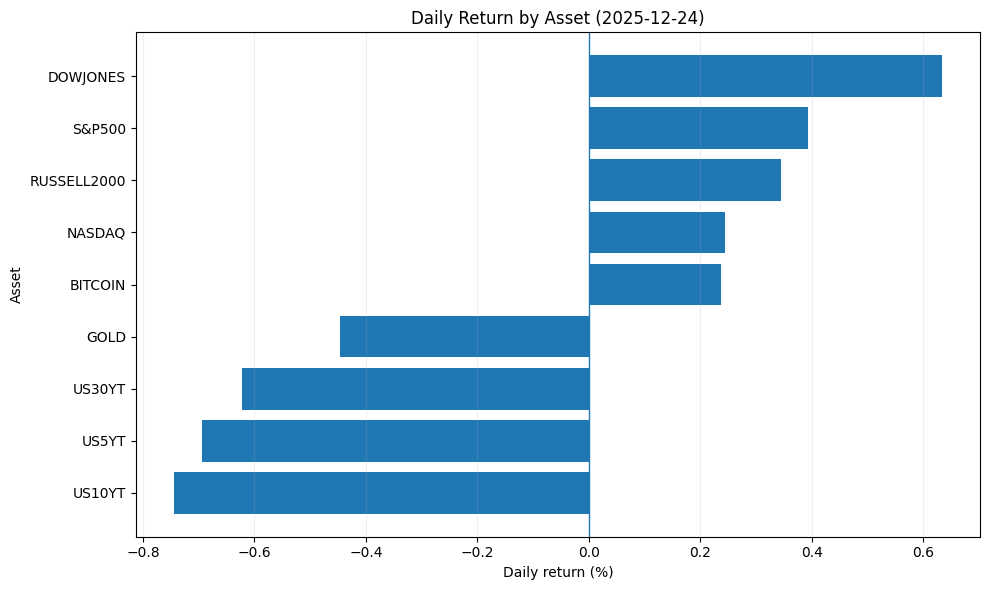

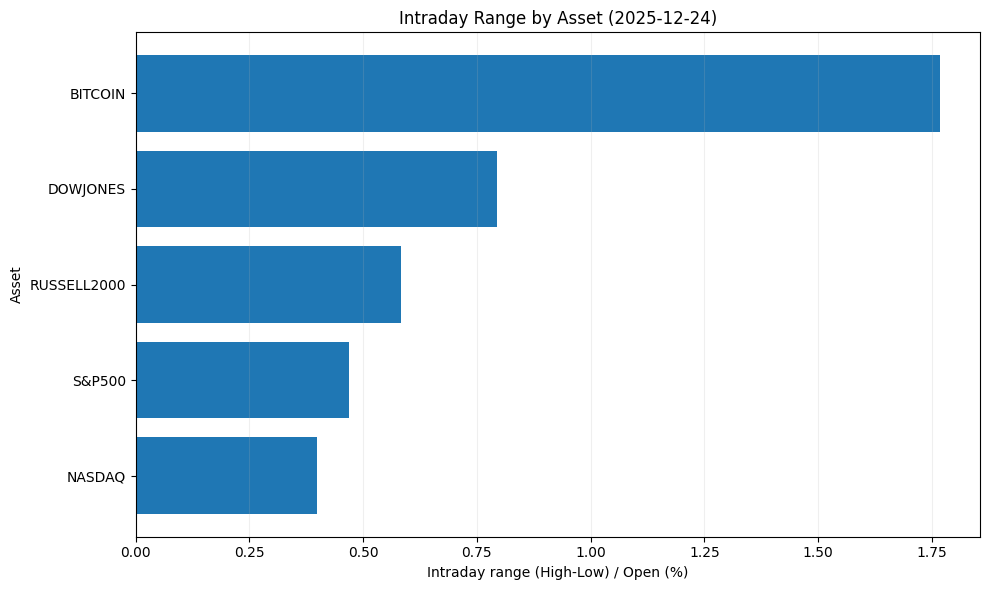

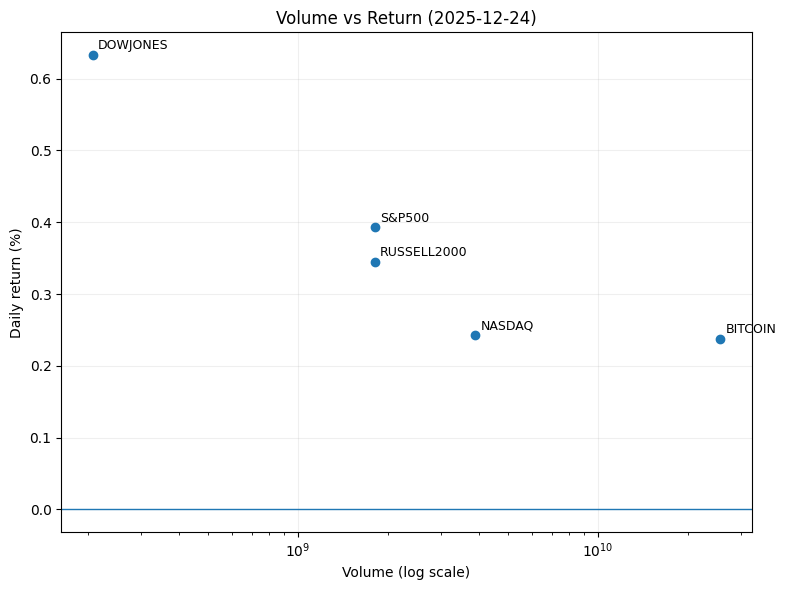

In [19]:
temp_1 = plot_daily_return_bar(df[~df['stock'].isin(['VIX', 'Dallor Index/USD', 'USD/KRW'])]).savefig(f'./figs/{folder_name}/DailyReturn.png')
temp_1 = plot_intraday_range_bar(df[df['stock'].isin(stock_list)]).savefig(f"./figs/{folder_name}/IntradayRange.png")
temp_1 = plot_volume_vs_return_scatter(df[df['stock'].isin(stock_list)]).savefig(f"./figs/{folder_name}/volume_vs_return.png")